Data Loading

In [1]:
import pandas as pd

#Exclude Columns Related to Data on the Specific Director.
#Want this to be a tool for new directors/producers trying to break in
# So I don't want the model tied to director details
# Also drop the unused genres list column
cols_to_exclude = ["genres","director_name","director_professions","director_birthYear","director_deathYear", "Production budget $"]

target_cols = ["movie_title","Production budget $"]


x = pd.read_csv("movie_statistic_dataset_processed.csv",usecols=lambda column: column not in cols_to_exclude)
y = pd.read_csv("movie_statistic_dataset_processed.csv",usecols=target_cols)
# Convert Year String to Int
x['production_date'] = pd.to_datetime(x['production_date']).dt.year.astype(int)

#Set the title as the index
x = x.set_index('movie_title')
y = y.set_index('movie_title')

# Total entries
print(f'Total Rows: {len(x)}')
#Check for bad runtime (i.e. runtime of 0 or NA) or no budget data
non_zero_runtime = (x['runtime_minutes']!=0).sum()
non_zero_budget= (y['Production budget $']!=0).sum()
print(f'Entries with Non-Zero Runtime: {non_zero_runtime}')
print(f'Entries with Non-Zero Budget: {non_zero_budget}')

# Check the head of the data
#print(f'Head of X: {x.head()}')
#print(f'Head of Y: {y.head()}')

# Describe the Dataset
print(f'Summary: {x.describe()}')

Total Rows: 4380
Entries with Non-Zero Runtime: 4380
Entries with Non-Zero Budget: 4380
Summary:        production_date  runtime_minutes  movie_averageRating  \
count      4380.000000      4380.000000          4380.000000   
mean       2003.842237       109.786073             6.407443   
std          13.442646        20.375581             1.024000   
min        1915.000000        63.000000             1.500000   
25%        1999.000000        96.000000             5.800000   
50%        2006.000000       106.000000             6.500000   
75%        2013.000000       120.000000             7.100000   
max        2023.000000       271.000000             9.300000   

       movie_numerOfVotes  approval_Index  Domestic gross $  \
count        4.380000e+03     4380.000000      4.380000e+03   
mean         1.369603e+05        5.032633      5.256385e+07   
std          2.150757e+05        1.384890      7.508813e+07   
min          5.000000e+00        0.395487      2.640000e+02   
25%        

Split Data into Training and Testing

In [2]:
from sklearn.model_selection import train_test_split
#Split the data
rand_seed=1
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=rand_seed) 


Regression With Polynomial Features

In [3]:
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

training_mses = []
training_r = []
testing_mses = []
testing_r = []

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


for degree in range(1,6):
    print(f'Degree: {degree}')
    poly = PolynomialFeatures(degree=degree, include_bias=False) 
    X_train_poly = poly.fit_transform(X_train_scaled) 
    X_test_poly = poly.transform(X_test_scaled)


    #X_val_poly = poly.transform(X_train_scaled) 
    model = LinearRegression() 
    model.fit(X_train_poly, y_train)


    # Predict with the model on the training set and testing set for MSE determination
    Y_train_predict = model.predict(X_train_poly)
    Y_test_predict = model.predict(X_test_poly)

    # MSE Test
    mse_test = mean_squared_error(y_test, Y_test_predict)
    r_test = r2_score(y_test, Y_test_predict)
    
    # Add to array
    testing_mses.append(mse_test)
    testing_r.append(r_test)
    #print(f"MSE Validation: {mse_test}")
  

    #MSE TRAINING
    mse_train = mean_squared_error(y_train, Y_train_predict )
    r_train = r2_score(y_train, Y_train_predict)
    training_mses.append(mse_train)
    training_r.append(r_train)
    #print(f"MSE Testing: {mse_train}")
#MSE Results
print(f"MSE Training Results: {training_mses}")
print(f"R^2 Training Results: {training_r}")
print(f"MSE Testing Results: {testing_mses}")
print(f"R^2 Testing Results: {testing_r}")


Degree: 1
Degree: 2
Degree: 3
Degree: 4
Degree: 5
MSE Training Results: [678415097676630.5, 439658295763788.0, 198796913745100.53, 547136647877.76685, 182552544710.42847]
R^2 Training Results: [0.6719251729061094, 0.7873855993814389, 0.9038637799673344, 0.9997354101319915, 0.9999117193960652]
MSE Testing Results: [673824738710344.0, 528646157189002.5, 7.080433163889345e+16, 9.041419724796189e+21, 1.6980077797959876e+21]
R^2 Testing Results: [0.6916603894350382, 0.758093550340261, -31.399790019038768, -4137317.915054587, -777000.8336825023]


Plotting of Linear Regression with Basis Expansion

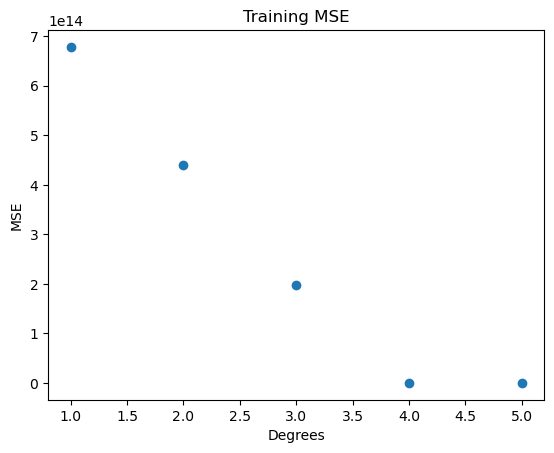

In [4]:
import matplotlib.pyplot as plt
plt.scatter(range(1,6),training_mses)
plt.xlabel("Degrees")
plt.ylabel("MSE")
plt.title("Training MSE")
plt.show()


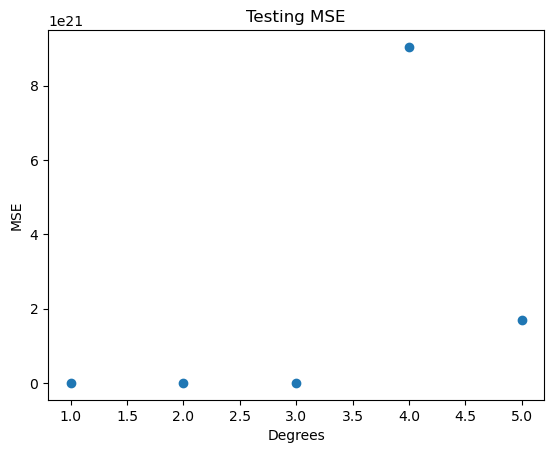

In [5]:
plt.scatter(range(1,6),testing_mses)
plt.xlabel("Degrees")
plt.ylabel("MSE")
plt.title("Testing MSE")
plt.show()

In [6]:
# Best Model So Far
min_training_index = training_mses.index(min(training_mses))
min_testing_index = testing_mses.index(min(testing_mses))
print(f'Degree of Min Training MSE: {min_training_index+1}')
print(f'Degree of Min Testing MSE: {min_testing_index+1}')

Degree of Min Training MSE: 5
Degree of Min Testing MSE: 2


In [7]:
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt

# RidgeCV Normalization
ridge_training_mses= []
ridge_training_r=[]
ridge_testing_mses=[]
ridge_testing_r=[]

for degree in range(1,6):
    print(f'Degree: {degree}')
    poly = PolynomialFeatures(degree=degree, include_bias=False) 
    X_train_poly = poly.fit_transform(X_train_scaled) 
    X_test_poly = poly.transform(X_test_scaled)


    #X_val_poly = poly.transform(X_train_scaled) 
    model = RidgeCV(alphas=[0.1, 1,10,100,1000,10000,100000,1000000,10000000,100000000]) 
    model.fit(X_train_poly, y_train)
    print(f"Best Alpha:{model.alpha_}")


    # Predict with the model on the training set and testing set for MSE determination
    Y_train_predict = model.predict(X_train_poly)
    Y_test_predict = model.predict(X_test_poly)

    # MSE Test
    mse_test = mean_squared_error(y_test, Y_test_predict)
    r_test = r2_score(y_test, Y_test_predict)
    
    # Add to array
    ridge_testing_mses.append(mse_test)
    ridge_testing_r.append(r_test)
    #print(f"MSE Validation: {mse_test}")
  

    #MSE TRAINING
    mse_train = mean_squared_error(y_train, Y_train_predict )
    r_train = r2_score(y_train, Y_train_predict)
    ridge_training_mses.append(mse_train)
    ridge_training_r.append(r_train)
    #print(f"MSE Testing: {mse_train}")
#MSE Results
print(f"MSE ridge Training Results: {ridge_training_mses}")
print(f"R^2 ridge Training Results: {ridge_training_r}")
print(f"MSE ridge Testing Results: {ridge_testing_mses}")
print(f"R^2 ridge Testing Results: {ridge_testing_r}")

# Best Ridge So Far
min_training_index_r = ridge_training_mses.index(min(ridge_training_mses))
min_testing_index_r = ridge_testing_mses.index(min(ridge_testing_mses))
print(f'Degree of Min Training MSE RIDGE: {min_training_index_r+1}')
print(f'Degree of Min Testing MSE RIDGE: {min_testing_index_r+1}')

Degree: 1
Best Alpha:10.0
Degree: 2
Best Alpha:100.0
Degree: 3
Best Alpha:10000.0
Degree: 4
Best Alpha:1000000.0
Degree: 5
Best Alpha:100000000.0
MSE ridge Training Results: [678514944141688.1, 456172013466608.4, 462881645083547.6, 746033451665910.4, 1106312976842683.8]
R^2 ridge Training Results: [0.6718768881437687, 0.7793997289334135, 0.7761550174873832, 0.6392256061226171, 0.4649979933636528]
MSE ridge Testing Results: [675579268135743.1, 528223242540467.3, 572579679354100.0, 1007089545847545.0, 1363185865849499.8]
R^2 ridge Testing Results: [0.6908575235135705, 0.7582870744579435, 0.7379897394575377, 0.5391596946039682, 0.37621138723970315]
Degree of Min Training MSE RIDGE: 2
Degree of Min Testing MSE RIDGE: 2
